In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
loan = pd.read_csv("loan_approval_data.csv")

# Introduction to Data

In [3]:
# Introduction Data
loan.info()
loan.isnull().sum()
loan.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handel Missing Value

In [4]:
categorical_cols = loan.select_dtypes(include = ["object"]).columns
num_cols = loan.select_dtypes(include = ["number"]).columns

C:\Users\klynt\AppData\Local\Temp\ipykernel_13932\2387327798.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = loan.select_dtypes(include = ["object"]).columns


In [5]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = 'mean')
loan[num_cols] = num_imp.fit_transform(loan[num_cols])

In [6]:
categorical_imp = SimpleImputer(strategy = 'most_frequent')
loan[categorical_cols] = categorical_imp.fit_transform(loan[categorical_cols])

In [7]:
loan.head()
loan.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EXPLORATORY DATA ANALYSIS - EDA

Text(0.5, 1.0, 'Loan Approved Or Not')

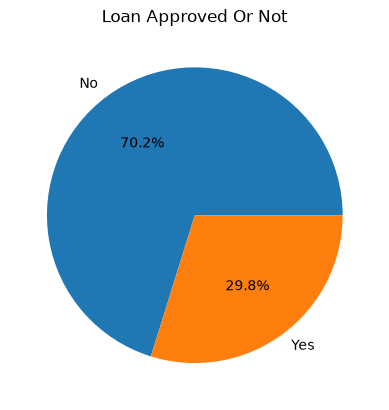

In [8]:
# How balance clases are

class_count = loan["Loan_Approved"].value_counts()
plt.pie(class_count, labels = ["No", "Yes"], autopct = "%1.1f%%")
plt.title("Loan Approved Or Not")

[Text(0, 0, '722'), Text(0, 0, '278')]

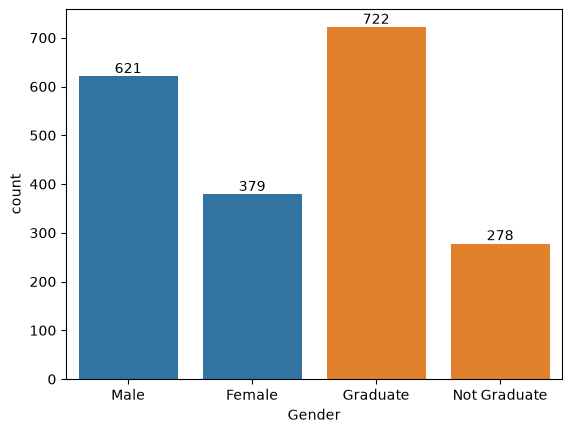

In [9]:
#  Analyse Catogeries

gender_cnt = loan["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

edu_cnt = loan["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[1])


<Axes: xlabel='Applicant_Income', ylabel='Count'>

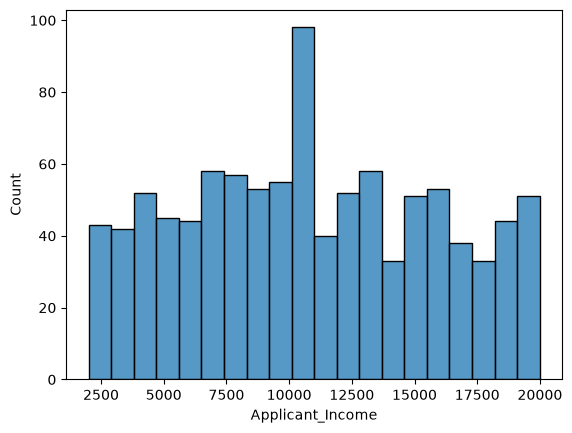

In [10]:
#  Analyze Income

sns.histplot(
    data = loan,
    x = "Applicant_Income",
    bins = 20
)


<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

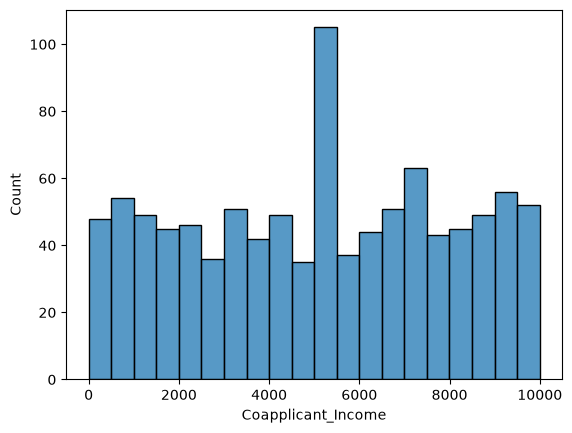

In [11]:
#  Analyze C0 - Income

sns.histplot(
    data = loan,
    x = "Coapplicant_Income",
    bins = 20
)


<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

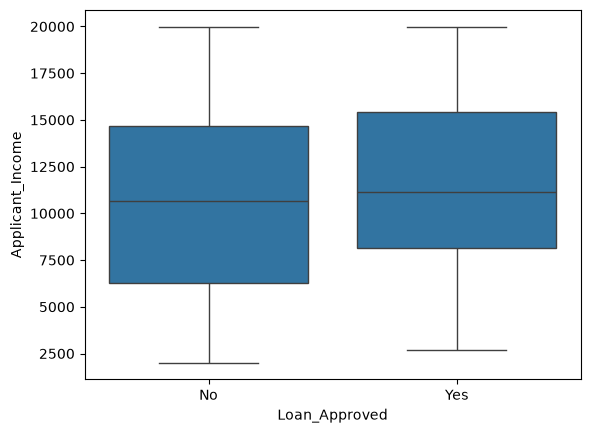

In [12]:
# Outlier Detection

sns.boxplot(
    data = loan,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

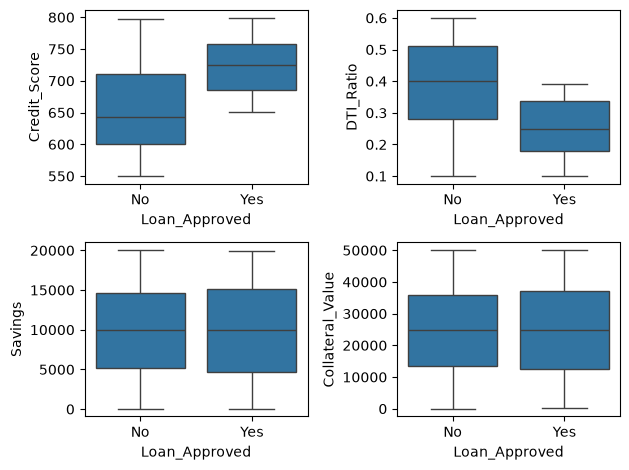

In [13]:
fig, axes = plt.subplots(2, 2)

sns.boxplot(ax = axes[0,0], data = loan, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[0,1], data = loan, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = axes[1,0], data = loan, x = "Loan_Approved", y = "Savings")
sns.boxplot(ax = axes[1,1], data = loan, x = "Loan_Approved", y = "Collateral_Value")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

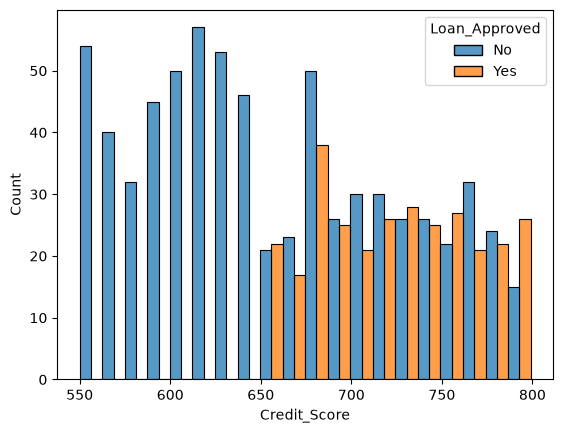

In [14]:
# Analyze credit score with loan approved

sns.histplot(
    data = loan,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)

In [15]:
# Remove Applicant ID:

loan = loan.drop("Applicant_ID", axis = 1)
loan.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# ENCODING

In [16]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   str    
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   str    
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   str    
 16  Gender            

In [17]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
loan["Education_Level"] = le.fit_transform(loan["Education_Level"])
loan["Loan_Approved"] = le.fit_transform(loan["Loan_Approved"])

In [18]:
# ONE HOT ENCODING
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]
ohe = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")
encoded = ohe.fit_transform(loan[cols])
encoded_loan = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = loan.index)

loan = pd.concat([loan.drop(columns = cols), encoded_loan], axis = 1)

In [19]:
loan.head()
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved                   

# CORRELATION HEATMAP

<Axes: >

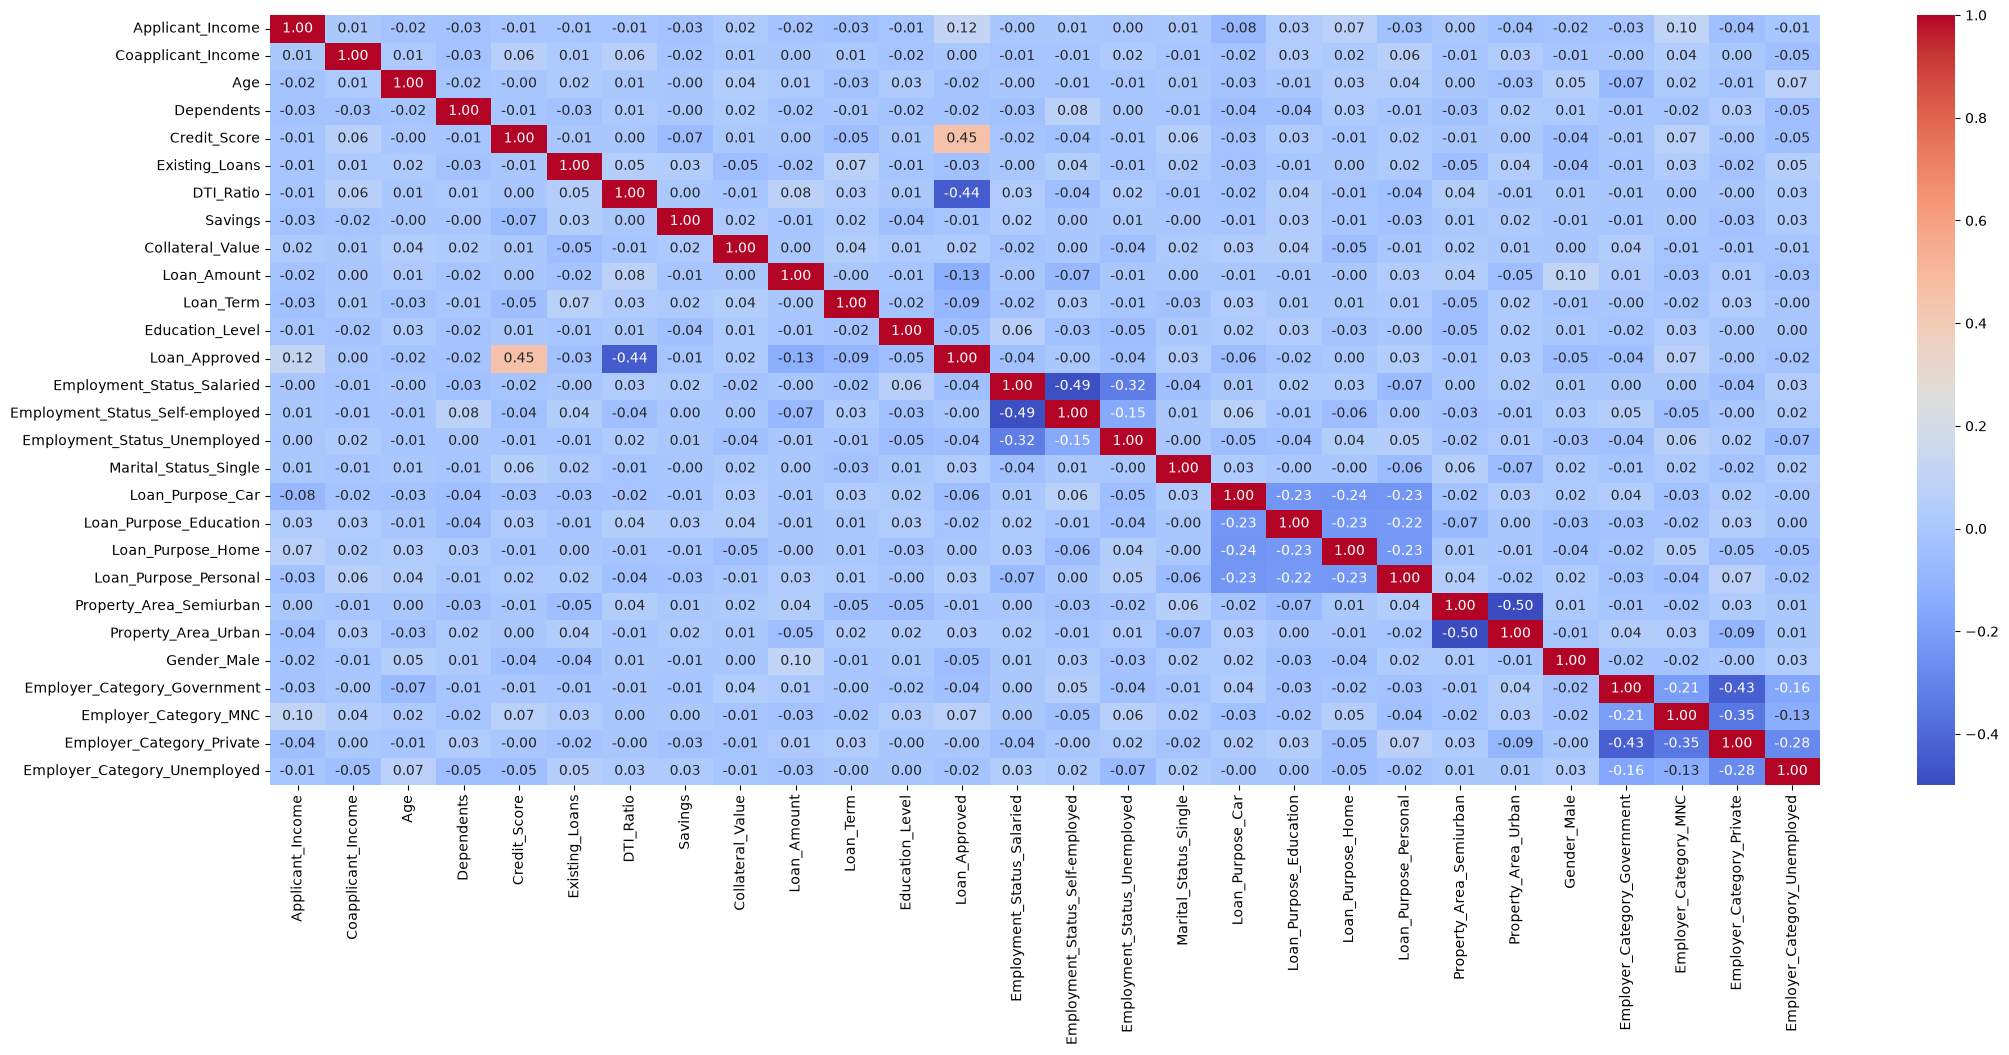

In [20]:
num_cols = loan.select_dtypes(include = "number")

corr_matrix = num_cols.corr()


plt.figure(figsize = (25, 10))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [21]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Training - Testing - Spliting  + Feature Scaling

In [22]:
X = loan.drop("Loan_Approved", axis = 1)
y = loan["Loan_Approved"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TRAIN AND EVALUATE MODEL

## ----------LOGISTIC REGRESSION------------

In [25]:
# LOGISTICS REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix, f1_score



log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation

print("--------LOGISTIC REGRESSION----------")
print(f"1. Precision Score: {precision_score(y_test, y_pred)}")
print(f"2. Recal Score: {recall_score(y_test, y_pred)}")
print(f"3. Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"4. F1 Score: {f1_score(y_test, y_pred)}")
print(f"5. CM: {confusion_matrix(y_test, y_pred)}")

--------LOGISTIC REGRESSION----------
1. Precision Score: 0.7833333333333333
2. Recal Score: 0.7704918032786885
3. Accuracy Score: 0.865
4. F1 Score: 0.7768595041322314
5. CM: [[126  13]
 [ 14  47]]


## --------kNN MODEL-----------

In [26]:
# KNN - K-Neighbore

from sklearn.neighbors import KNeighborsClassifier




knn_model = KNeighborsClassifier(n_neighbors = 9)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation

print("--------kNN MODEL----------")
print(f"1. Precision Score: {precision_score(y_test, y_pred)}")
print(f"2. Recal Score: {recall_score(y_test, y_pred)}")
print(f"3. Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"4. F1 Score: {f1_score(y_test, y_pred)}")
print(f"5. CM: {confusion_matrix(y_test, y_pred)}")

--------kNN MODEL----------
1. Precision Score: 0.6585365853658537
2. Recal Score: 0.4426229508196721
3. Accuracy Score: 0.76
4. F1 Score: 0.5294117647058824
5. CM: [[125  14]
 [ 34  27]]


## ------------NAIVE BAYES ---------------

In [27]:
# Naive-BAYES

from sklearn.naive_bayes import GaussianNB




nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation

print("--------NAIVE BAYES MODEL----------")
print(f"1. Precision Score: {precision_score(y_test, y_pred)}")
print(f"2. Recal Score: {recall_score(y_test, y_pred)}")
print(f"3. Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"4. F1 Score: {f1_score(y_test, y_pred)}")
print(f"5. CM: {confusion_matrix(y_test, y_pred)}")

--------NAIVE BAYES MODEL----------
1. Precision Score: 0.8035714285714286
2. Recal Score: 0.7377049180327869
3. Accuracy Score: 0.865
4. F1 Score: 0.7692307692307693
5. CM: [[128  11]
 [ 16  45]]


## BEST MODEL - NAIVE BAYES

# FEATURE ENGINEERING

In [28]:
loan["DTI_Ratio_sq"] = loan["DTI_Ratio"] ** 2
loan["Credit_Score_sq"] = loan["Credit_Score"] ** 2

loan["Applicant_Income_log"] = np.log1p(loan["Applicant_Income"])

X = loan.drop(columns = ["Loan_Approved", "DTI_Ratio", "Credit_Score", "Applicant_Income"])
y = loan["Loan_Approved"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Scaling the features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
# LOGISTICS REGRESSION
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("--------LOGISTIC REGRESSION----------")
print(f"1. Precision Score: {precision_score(y_test, y_pred)}")
print(f"2. Recal Score: {recall_score(y_test, y_pred)}")
print(f"3. Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"4. F1 Score: {f1_score(y_test, y_pred)}")
print(f"5. CM: {confusion_matrix(y_test, y_pred)}")

--------LOGISTIC REGRESSION----------
1. Precision Score: 0.7777777777777778
2. Recal Score: 0.8032786885245902
3. Accuracy Score: 0.87
4. F1 Score: 0.7903225806451613
5. CM: [[125  14]
 [ 12  49]]


In [30]:
# knn Model
knn_model = KNeighborsClassifier(n_neighbors = 9)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation

print("--------kNN MODEL----------")
print(f"1. Precision Score: {precision_score(y_test, y_pred)}")
print(f"2. Recal Score: {recall_score(y_test, y_pred)}")
print(f"3. Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"4. F1 Score: {f1_score(y_test, y_pred)}")
print(f"5. CM: {confusion_matrix(y_test, y_pred)}")

--------kNN MODEL----------
1. Precision Score: 0.6829268292682927
2. Recal Score: 0.45901639344262296
3. Accuracy Score: 0.77
4. F1 Score: 0.5490196078431373
5. CM: [[126  13]
 [ 33  28]]


In [31]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation

print("--------NAIVE BAYES MODEL----------")
print(f"1. Precision Score: {precision_score(y_test, y_pred)}")
print(f"2. Recal Score: {recall_score(y_test, y_pred)}")
print(f"3. Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"4. F1 Score: {f1_score(y_test, y_pred)}")
print(f"5. CM: {confusion_matrix(y_test, y_pred)}")

--------NAIVE BAYES MODEL----------
1. Precision Score: 0.8035714285714286
2. Recal Score: 0.7377049180327869
3. Accuracy Score: 0.865
4. F1 Score: 0.7692307692307693
5. CM: [[128  11]
 [ 16  45]]
